# Model Comparison

This notebook compares the non-keyboard agents used in `game_render.py` over `num_run` game sessions per model.

It reports average score, ticks survived, and waves reached, then visualizes the per-run distributions.

Note: score is cumulative reward from the environment, so a model can survive longer but still score lower if its actions trigger fewer positive rewards or more penalties.

In [1]:
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agents import (
    PlayerV2,
    PlayerQ,
    ReinforceAgentV2,
    ACAgent3,
    TrainerAC3,
    RandomAgent,
    DoNothingAgent,
    HeuristicAgent,
)
from pvz import config
import torch

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
num_run = 100

LEGACY_DDQN_MODEL = "agents/agent_zoo/dfq5_epsexp"
DDQN_RENDER_MODEL = "agents/agent_zoo/ddqn_new"
DDQN_NEW_MODEL = "agents/agent_zoo/ddqn_tfx"
REINFORCE_MODEL = "agents/agent_zoo/dfp5"
AC_POLICY_MODEL_1 = "agents/agent_zoo/actor-critic/ac_t_v1_policy.pt"
AC_VALUE_MODEL_1 = "agents/agent_zoo/actor-critic/ac_t_v1_value.pt"
AC_POLICY_MODEL_2 = "agents/agent_zoo/actor-critic/ac_t_v2_policy.pt"
AC_VALUE_MODEL_2 = "agents/agent_zoo/actor-critic/ac_t_v2_value.pt"
AC_POLICY_MODEL_3 = "agents/agent_zoo/actor-critic/ac_t_v3_policy.pt"
AC_VALUE_MODEL_3 = "agents/agent_zoo/actor-critic/ac_t_v3_value.pt"

In [3]:
def scene_stats(env):
    base_env = getattr(env, "env", env)
    base_env = getattr(base_env, "unwrapped", base_env)
    scene = getattr(base_env, "_scene", None)
    if scene is None:
        return 0, 0

    chrono = getattr(scene, "_chrono", 0)
    wave = getattr(getattr(scene, "_zombie_spawner", None), "_wave_index", 0)
    return chrono, wave


def run_one_session(env, agent):
    summary = env.play(agent)
    try:
        score = float(np.sum(summary["raw_rewards"]))
    except KeyError:
        score = float(np.sum(summary["rewards"]))
    chrono, wave = scene_stats(env)
    ticks_survived = int(min(chrono, config.MAX_SECONDS))
    return {
        "score": score,
        "ticks_survived": ticks_survived,
        "waves": int(wave),
    }


def run_agent(label, env, agent, runs=num_run):
    rows = []
    for run_index in range(1, runs + 1):
        metrics = run_one_session(env, agent)
        metrics["model"] = label
        metrics["run"] = run_index
        rows.append(metrics)
    return pd.DataFrame(rows)


agent_specs = []

In [4]:
missing_models = []
agent_specs = []


def add_spec(model, make_env, make_agent, load=None, checkpoint_paths=None):
    if checkpoint_paths is not None:
        if isinstance(checkpoint_paths, str):
            paths = [checkpoint_paths]
        else:
            paths = list(checkpoint_paths)
        if not all(Path(path).exists() for path in paths):
            missing_models.append(model)
            return
    agent_specs.append({
        "model": model,
        "make_env": make_env,
        "make_agent": make_agent,
        "load": load or (lambda agent: agent),
    })


add_spec(
    "Reinforce",
    make_env=lambda: PlayerV2(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: ReinforceAgentV2(
        input_size=env.num_observations(),
        possible_actions=env.get_actions(),
    ),
    load=lambda agent: agent.load(REINFORCE_MODEL),
    checkpoint_paths=REINFORCE_MODEL,
)

add_spec(
    "DDQN_Legacy",
    make_env=lambda: PlayerQ(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: torch.load(DDQN_RENDER_MODEL, weights_only=False),
    checkpoint_paths=DDQN_RENDER_MODEL,
)

add_spec(
    "DDQN_New",
    make_env=lambda: PlayerQ(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: torch.load(DDQN_NEW_MODEL, weights_only=False),
    checkpoint_paths=DDQN_NEW_MODEL,
)

add_spec(
    "Actor-Critic 1",
    make_env=lambda: TrainerAC3(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: ACAgent3(
        input_size=env.num_observations(),
        possible_actions=env.get_actions(),
    ),
    load=lambda agent: agent.load(AC_POLICY_MODEL_1, AC_VALUE_MODEL_1),
    checkpoint_paths=[AC_POLICY_MODEL_1, AC_VALUE_MODEL_1],
)

add_spec(
    "Actor-Critic 2",
    make_env=lambda: TrainerAC3(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: ACAgent3(
        input_size=env.num_observations(),
        possible_actions=env.get_actions(),
    ),
    load=lambda agent: agent.load(AC_POLICY_MODEL_2, AC_VALUE_MODEL_2),
    checkpoint_paths=[AC_POLICY_MODEL_2, AC_VALUE_MODEL_2],
)

add_spec(
    "Actor-Critic 3",
    make_env=lambda: TrainerAC3(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: ACAgent3(
        input_size=env.num_observations(),
        possible_actions=env.get_actions(),
    ),
    load=lambda agent: agent.load(AC_POLICY_MODEL_3, AC_VALUE_MODEL_3),
    checkpoint_paths=[AC_POLICY_MODEL_3, AC_VALUE_MODEL_3],
)

add_spec(
    "Heuristic",
    make_env=lambda: PlayerQ(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: HeuristicAgent(possible_actions=env.get_actions()),
)

add_spec(
    "DummyRandom",
    make_env=lambda: PlayerQ(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: RandomAgent(possible_actions=env.get_actions()),
)

add_spec(
    "DummyDoNothing",
    make_env=lambda: PlayerQ(render=False, max_waves=config.MAX_WAVE),
    make_agent=lambda env: DoNothingAgent(),
)

if missing_models:
    print("Skipped missing checkpoints:", ", ".join(missing_models))

results = []

for spec in agent_specs:
    env = spec["make_env"]()
    agent = spec["make_agent"](env)
    spec["load"](agent)
    print(f"Running agent: {spec['model']}...")
    results.append(run_agent(spec["model"], env, agent, runs=num_run))

results_df = pd.concat(results, ignore_index=True)
summary_df = (
    results_df.groupby("model", as_index=False)
    .agg(
        score_mean=("score", "mean"),
        score_std=("score", "std"),
        ticks_survived_mean=("ticks_survived", "mean"),
        ticks_survived_std=("ticks_survived", "std"),
        waves_mean=("waves", "mean"),
        waves_std=("waves", "std"),
    )
    .fillna(0.0)
)

model_order = [spec["model"] for spec in agent_specs]
results_df["model"] = pd.Categorical(results_df["model"], categories=model_order, ordered=True)
summary_df["model"] = pd.Categorical(summary_df["model"], categories=model_order, ordered=True)
summary_df = summary_df.sort_values("model").reset_index(drop=True)

results_df

Skipped missing checkpoints: Reinforce
Running agent: DDQN_Legacy...


/opt/homebrew/lib/python3.9/site-packages/gym/envs/registration.py:498: UserWarning: WARN: Overriding environment pvz-env-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


Running agent: DDQN_New...
Running agent: Actor-Critic 1...
Running agent: Actor-Critic 2...
Running agent: Actor-Critic 3...
Running agent: Heuristic...
Running agent: DummyRandom...
Running agent: DummyDoNothing...


,score,ticks_survived,waves,model,run
0,5067.0,200,7,DDQN_Legacy,1
1,2225.0,150,6,DDQN_Legacy,2
2,2093.0,150,6,DDQN_Legacy,3
3,2531.0,150,6,DDQN_Legacy,4
4,4178.0,200,7,DDQN_Legacy,5
...,...,...,...,...,...
795,1911.0,134,4,DummyDoNothing,96
796,1523.0,109,4,DummyDoNothing,97
797,2062.0,155,6,DummyDoNothing,98
798,1663.0,117,4,DummyDoNothing,99


,model,score_mean,score_std,ticks_survived_mean,ticks_survived_std,waves_mean,waves_std
0,DDQN_Legacy,3028.64,1023.102289,170.00,25.623537,6.13,0.812217
1,DDQN_New,31326.15,22186.916754,743.25,427.697155,19.62,9.853246
2,Actor-Critic 1,43574.85,23970.587829,954.08,438.947816,24.37,9.719973
3,Actor-Critic 2,70637.92,17712.157664,1398.82,263.197870,33.77,5.106650
4,Actor-Critic 3,55337.21,15963.502702,1164.50,278.267639,29.04,5.966100
5,Heuristic,2151.89,494.605422,145.48,20.799903,5.37,0.836720
6,DummyRandom,5626.31,7626.590906,231.45,181.322492,7.65,4.549115
7,DummyDoNothing,1871.50,278.299508,127.48,17.328368,4.62,0.788554


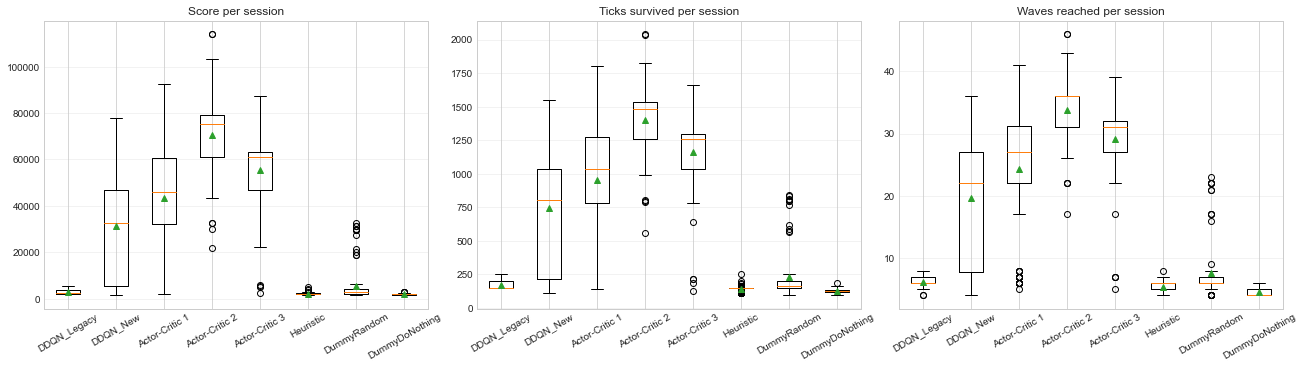

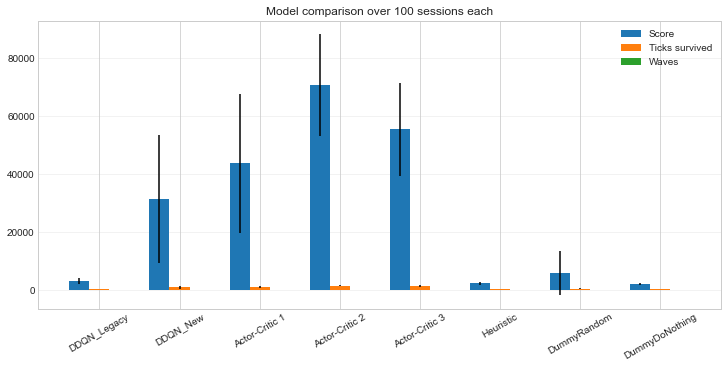

In [5]:
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
metrics = [
    ("score", "Score per session"),
    ("ticks_survived", "Ticks survived per session"),
    ("waves", "Waves reached per session"),
]

for ax, (metric, title) in zip(axes, metrics):
    series = [results_df.loc[results_df["model"] == model, metric].to_numpy() for model in model_order]
    ax.boxplot(series, labels=model_order, showmeans=True)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)

plt.show()

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
bar_width = 0.25
x = np.arange(len(summary_df))
ax.bar(x - bar_width, summary_df["score_mean"], bar_width, yerr=summary_df["score_std"], label="Score")
ax.bar(x, summary_df["ticks_survived_mean"], bar_width, yerr=summary_df["ticks_survived_std"], label="Ticks survived")
ax.bar(x + bar_width, summary_df["waves_mean"], bar_width, yerr=summary_df["waves_std"], label="Waves")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["model"], rotation=30)
ax.set_title(f"Model comparison over {num_run} sessions each")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.show()

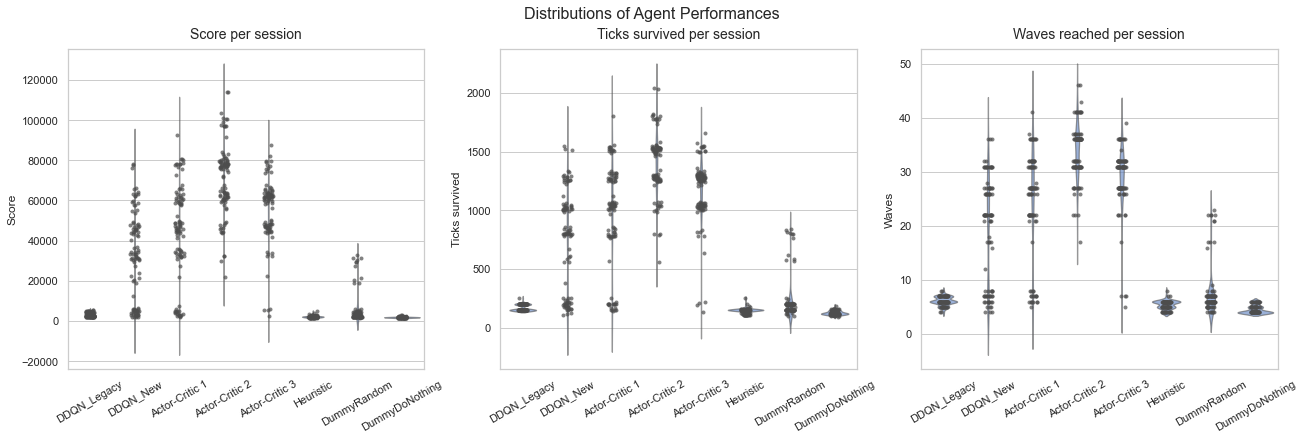

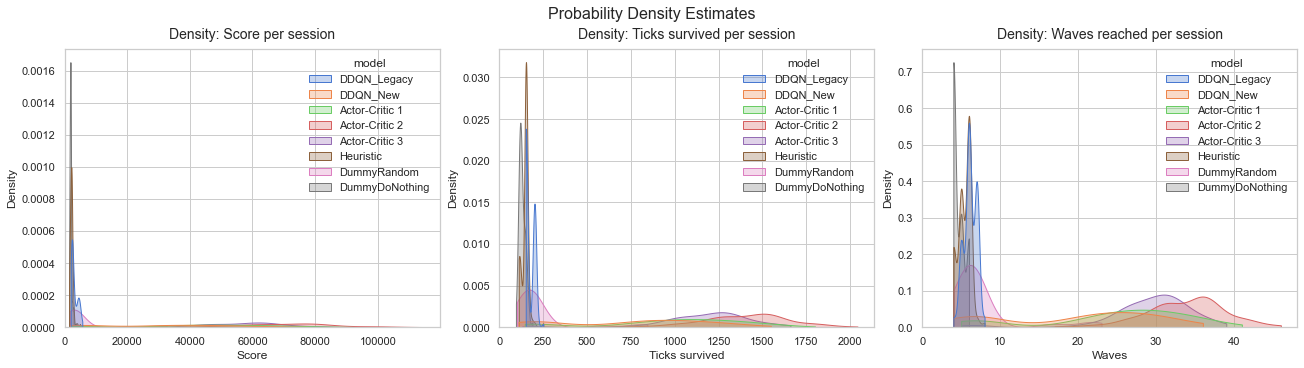

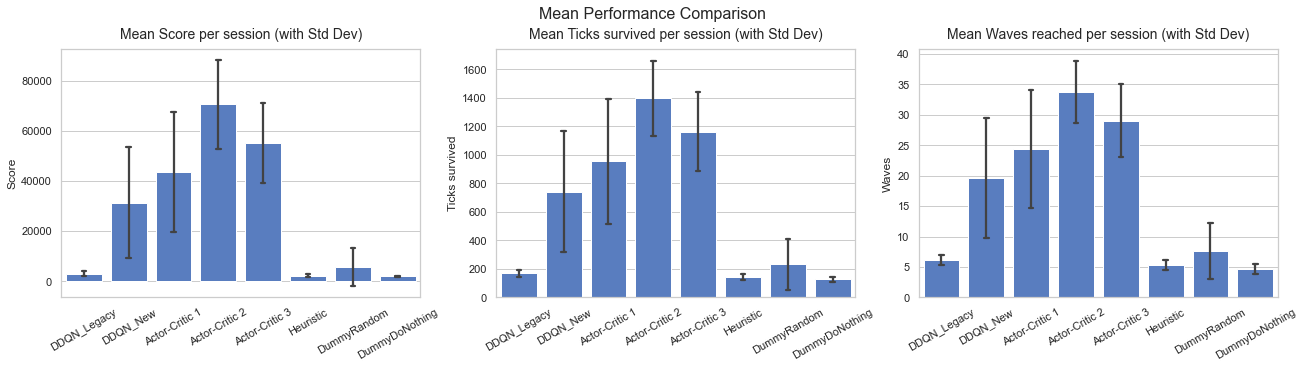

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn theme for better aesthetics
sns.set_theme(style="whitegrid", palette="muted")

metrics = [
    ("score", "Score per session"),
    ("ticks_survived", "Ticks survived per session"),
    ("waves", "Waves reached per session"),
]

# 1. Violin plots with strip plots for data distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for ax, (metric, title) in zip(axes, metrics):
    sns.violinplot(data=results_df, x="model", y=metric, ax=ax, inner=None, alpha=0.6, order=model_order)
    sns.stripplot(data=results_df, x="model", y=metric, ax=ax, size=4, color=".3", jitter=True, order=model_order, alpha=0.7)
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel(metric.capitalize().replace("_", " "))
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Distributions of Agent Performances", fontsize=16)
plt.show()

# 2. KDE Plots to show probability density
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (metric, title) in zip(axes, metrics):
    sns.kdeplot(data=results_df, x=metric, hue="model", ax=ax, fill=True, common_norm=False, alpha=0.3, hue_order=model_order, cut=0, clip=(0, None))
    ax.set_title(f"Density: {title}", fontsize=14, pad=10)
    ax.set_xlabel(metric.capitalize().replace("_", " "))
    ax.set_xlim(left=0)
plt.suptitle("Probability Density Estimates", fontsize=16)
plt.show()

# 3. Bar charts for Mean Performance with Error Bars
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (metric, title) in zip(axes, metrics):
    sns.barplot(data=results_df, x="model", y=metric, ax=ax, errorbar="sd", capsize=.1, order=model_order)
    ax.set_title(f"Mean {title} (with Std Dev)", fontsize=14, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel(metric.capitalize().replace("_", " "))
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Mean Performance Comparison", fontsize=16)
plt.show()
